In [5]:
import torch
import torch.nn as nn
from torch.nn.utils import clip_grad_norm_
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import gc
import numpy as np
from privacy_analysis.compute_privacy_sgm import compute_dp_sgd_privacy

transform = transforms.Compose([
    transforms.ToTensor(),  
])

mnist_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
mnist_loader = DataLoader(dataset=mnist_dataset, batch_size=64, shuffle=True)

mnist_test_dataset = datasets.MNIST(root='./data', train=False, transform=transform, download=True)
test_loader = DataLoader(dataset=mnist_test_dataset, batch_size=1000, shuffle=False)

transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1), 
    transforms.Resize((28, 28)),               
    transforms.ToTensor(),                       
])

cifar_dataset = datasets.CIFAR10(root='./data', train=True, transform=transform, download=True)

private_subset = mnist_dataset

np.random.seed(42)
cifar_indices = np.random.choice(len(cifar_dataset), size=2500, replace=False)
public_subset = Subset(cifar_dataset, cifar_indices)

train_loader_private = DataLoader(dataset=private_subset, batch_size=64, shuffle=True)
train_loader_public = DataLoader(dataset=public_subset, batch_size=64, shuffle=True)

In [6]:
class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        self.conv1 = nn.Conv2d(1,6, kernel_size=5, stride=1, padding=2)
        self.tanh1 = nn.Tanh()
        self.pool1 = nn.AvgPool2d(kernel_size=2,  stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)
        self.tanh2 = nn.Tanh()
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)
        self.tanh3 = nn.Tanh()
        self.fc1 = nn.Linear(120, 84)
        self.tanh4 = nn.Tanh()
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool1(self.tanh1(self.conv1(x)))
        x = self.pool2(self.tanh2(self.conv2(x)))
        x = self.tanh3(self.conv3(x))
        x = x.view(-1, 120)
        x = self.tanh4(self.fc1(x))
        x = self.fc2(x)
        return x

model = mnist()
criterion = nn.CrossEntropyLoss()
epochs = 15
gc.collect()

806

In [7]:
def DOPESGD(model, D_loader, D_s_loader, test_loader, lr, sigma, l, T_public, T_private, delta, ADAPTIVE):
    """
    Parameters:
        D_loader: private training data loader
        n: private batch size
        D_s_loader: public training data loader
        n_s: public batch size
        lr: learning rate
        sigma: noise scale
        C: gradient norm clip
        l: loss function
        T_public: number of public training iterations
        T_private: number of private training iterations
    """

    train_losses_public = []
    train_accuracies_public = []
    test_losses_public = []
    test_accuracies_public = []

    total_gradients_public = []

    # n_private = len(D_loader.dataset)
    # batch_size_private = D_loader.batch_size
    
    optim = torch.optim.SGD(model.parameters(), lr)
    # pub_iter = iter(D_s_loader)

    for epoch in range(T_public):
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for inputs, labels in D_s_loader:
            optim.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            pub_grads = [p.grad.detach().clone() for p in model.parameters() if p.grad is not None]
            total_gradients_public.append(pub_grads)
            optim.step()
            total_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
        
        epoch_loss = total_loss / total
        epoch_accuracy = 100 * correct / total

        model.eval()
        correct = 0
        total = 0
        test_loss = 0.0

        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = l(outputs, labels)
                test_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total
        test_loss = test_loss / total

        train_losses_public.append(epoch_loss)
        train_accuracies_public.append(epoch_accuracy)
        test_losses_public.append(test_loss)
        test_accuracies_public.append(test_accuracy)

        print(f"Epoch [{epoch+1}/{T_public}] ... Training Loss: {epoch_loss:.4f} ",
              f"... Training Accuracy: {epoch_accuracy:.2f}% ... Test Loss: {test_loss:.4f} ... Test Accuracy: {test_accuracy:.2f}%")

    l2_norms = []

    for grads in total_gradients_public:
        total_norm = 0.0
        for g in grads:
            total_norm += torch.norm(g, p=2).item() ** 2
        l2_norm = total_norm ** 0.5
        l2_norms.append(l2_norm)

    progressive_clipping_norm = sum(l2_norms) / len(l2_norms)
    avg_pub_norm = sum(l2_norms) / len(l2_norms)
    print("AVG PUB NORM:", progressive_clipping_norm)

    train_losses_private = []
    train_accuracies_private = []
    test_losses_private = []
    test_accuracies_private = []

    n_private = len(D_loader.dataset)
    batch_size_private = D_loader.batch_size
    
    optim = torch.optim.SGD(model.parameters(), lr)
    pub_iter = iter(D_s_loader)

    for epoch in range(T_private):        
        model.train()
        total_loss = 0.0
        correct = 0
        total = 0

        for priv_inputs, priv_labels in D_loader:
            try:
                pub_inputs, pub_labels = next(pub_iter)
            except StopIteration:
                pub_iter = iter(D_s_loader)
                pub_inputs, pub_labels = next(pub_iter)
            
            optim.zero_grad()
            pub_out = model(pub_inputs)
            pub_loss = l(pub_out, pub_labels)
            pub_loss.backward()

            pub_grad_norm = 0.0
            for p in model.parameters():
                if p.grad is not None:
                    pub_grad_norm += p.grad.norm().item() ** 2
            pub_grad_norm = pub_grad_norm **0.5
            
            pub_grad = []
            for p in model.parameters():
                pub_grad.append(p.grad.detach().clone())
            pub_grad = [g.clone() for g in pub_grad]

            grads = [torch.zeros_like(p) for p in model.parameters()]

            # for x, y in zip(priv_inputs, priv_labels):
            #     optim.zero_grad()
            #     output = model(x.unsqueeze(0))
            #     loss = l(output, y.unsqueeze(0))
            #     loss.backward()

            #     # clip_grad_norm_(model.parameters(), progressive_clipping_norm)

            # for i, p in enumerate(model.parameters()):
            #     if p.requires_grad and p.grad is not None:
            #         grads[i] += pub_grad[i] + ((p.grad - pub_grad[i]) * progressive_clipping_norm) / (torch.max(torch.tensor(progressive_clipping_norm), torch.norm(p.grad - pub_grad[i])))

            # grads_noisy = []
            # for grad in grads:
            #     l2_norm = torch.norm(grad, p=2).item()
            #     grads_noisy.append(l2_norm)

            # progressive_clipping_norm = 0.7 * (sum(grads_noisy) / len(grads_noisy)) + 0.3 * progressive_clipping_norm

            grads = [torch.zeros_like(p) for p in model.parameters()]
            clipped_norms = []

            for x, y in zip(priv_inputs, priv_labels):
                optim.zero_grad()
                output = model(x.unsqueeze(0))
                loss = l(output, y.unsqueeze(0))
                loss.backward()

                for i, p in enumerate(model.parameters()):
                    if p.grad is not None:
                        diff = p.grad - pub_grad[i]
                        norm = torch.norm(diff)
                        scale = None
                        scale = progressive_clipping_norm / torch.max(torch.tensor(progressive_clipping_norm), norm)
                        clipped = diff * scale
                        grads[i] += clipped

                        if i == 0:
                            clipped_norms.append(torch.norm(clipped).item())

            if clipped_norms:
                avg_norm = sum(clipped_norms) / len(clipped_norms)
                progressive_clipping_norm = 0.7 * avg_norm + 0.3 * progressive_clipping_norm


            for i in range(len(grads)):    
                grads[i] += torch.normal(0, sigma * progressive_clipping_norm, grads[i].shape)
                noise = torch.normal(0, sigma * progressive_clipping_norm, grads[i].shape)

                
            for p, g in zip(model.parameters(), grads):
                if p.requires_grad:
                    p.grad = g / len(priv_inputs)
            optim.step()

            total_loss += pub_loss.item() * priv_inputs.size(0)
            with torch.no_grad():
                priv_out = model(priv_inputs)
                _, predicted = torch.max(priv_out.data, 1)
                total += priv_labels.size(0)
                correct += (predicted == priv_labels).sum().item()
        
        epoch_loss = total_loss / total
        epoch_accuracy = 100 * correct / total

        model.eval()
        correct = 0
        total = 0
        test_loss = 0.0

        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model(inputs)
                loss = l(outputs, labels)
                test_loss += loss.item() * labels.size(0)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        test_accuracy = 100 * correct / total
        test_loss = test_loss / total

        train_losses_private.append(epoch_loss)
        train_accuracies_private.append(epoch_accuracy)
        test_losses_private.append(test_loss)
        test_accuracies_private.append(test_accuracy)

        eps, _ = compute_dp_sgd_privacy(n_private, batch_size_private, sigma, epoch + 1, delta)

        print(f"Epoch [{epoch+1}/{T_private}] ... Training Loss: {epoch_loss:.4f} ... Training Accuracy: {epoch_accuracy:.2f}% ... Test Loss: {test_loss:.4f} ... Test Accuracy: {test_accuracy:.2f}% ... Epsilon: {eps:.4f} ... Delta: {delta}")

    return train_losses_private, train_accuracies_private, test_losses_private, test_accuracies_private

In [ ]:
train_losses, train_accuracies, test_losses, test_accuracies = DOPESGD(
                                                                        model=model,
                                                                        D_loader=train_loader_private,
                                                                        D_s_loader=train_loader_public,
                                                                        test_loader=test_loader,
                                                                        lr=0.01, 
                                                                        sigma=0.64, 
                                                                        # C=1.0,
                                                                        l=criterion,
                                                                        T_public=5,
                                                                        T_private=10,
                                                                        delta=1e-5,
                                                                        ADAPTIVE=True
                                                                      )

Epoch [1/5] ... Training Loss: 2.3049 ... Training Accuracy: 9.96% ... Test Loss: 2.3052 ... Test Accuracy: 6.46%
Epoch [2/5] ... Training Loss: 2.3039 ... Training Accuracy: 9.96% ... Test Loss: 2.3049 ... Test Accuracy: 4.92%
Epoch [3/5] ... Training Loss: 2.3032 ... Training Accuracy: 10.84% ... Test Loss: 2.3043 ... Test Accuracy: 5.02%
Epoch [4/5] ... Training Loss: 2.3025 ... Training Accuracy: 11.88% ... Test Loss: 2.3041 ... Test Accuracy: 9.17%
Epoch [5/5] ... Training Loss: 2.3020 ... Training Accuracy: 12.52% ... Test Loss: 2.3038 ... Test Accuracy: 10.87%
DP-SGD with sampling rate = 0.107% and noise_multiplier = 0.64 iterated over 938 steps satisfies differential privacy with eps = 2.15 and delta = 1e-05.
The optimal RDP order is 5.5.
Epoch [1/10] ... Training Loss: 2.3021 ... Training Accuracy: 12.83% ... Test Loss: 2.2963 ... Test Accuracy: 12.71% ... Epsilon: 2.1523 ... Delta: 1e-05
DP-SGD with sampling rate = 0.107% and noise_multiplier = 0.64 iterated over 1875 steps s

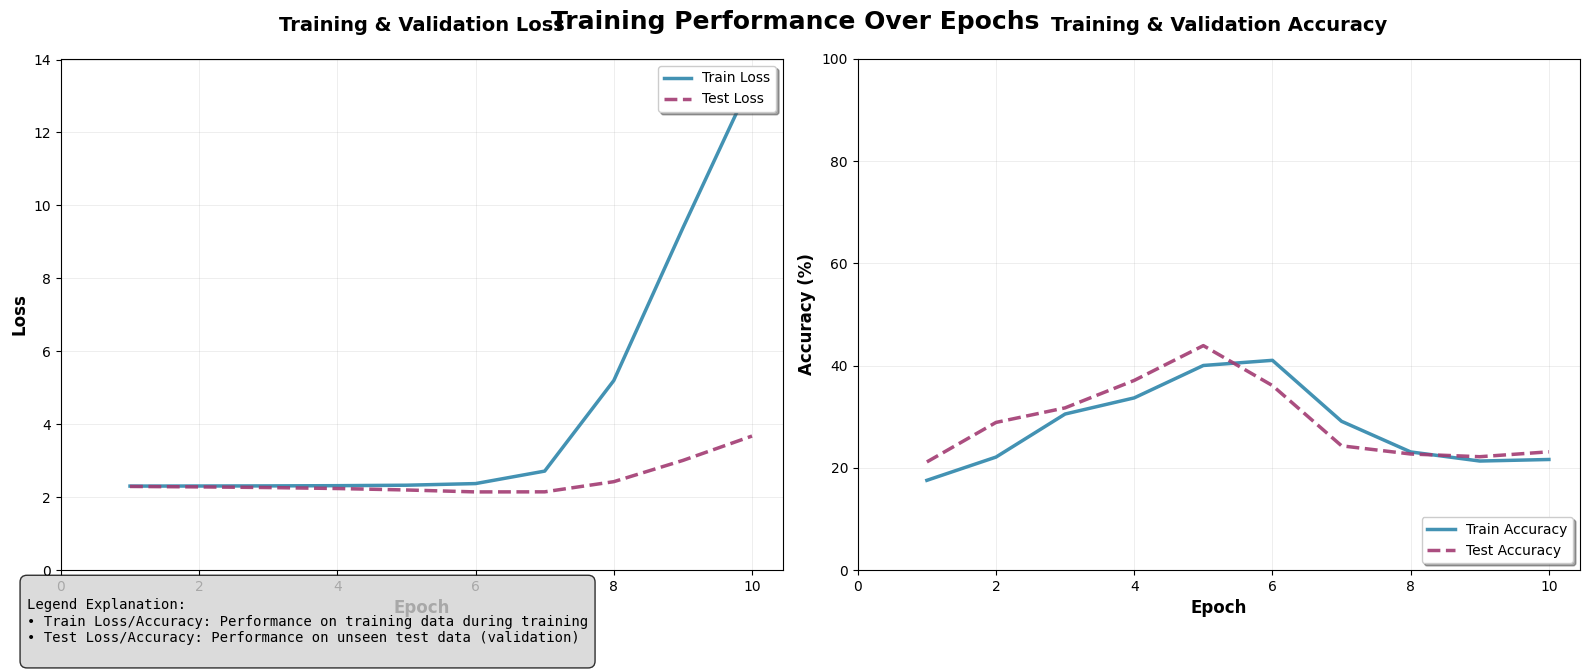

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Create epoch range
epochs = len(train_losses)
epoch_range = list(range(1, epochs + 1))

# Set up the figure
plt.rcParams.update({'font.size': 10})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Define color palette
train_color = '#2E86AB'     # Blue
test_color = '#A23B72'      # Red/Purple

# --- Loss Plot ---
ax1.plot(epoch_range, train_losses, color=train_color, linewidth=2.5, 
         label='Train Loss', alpha=0.9)
ax1.plot(epoch_range, test_losses, color=test_color, linewidth=2.5, 
         linestyle='--', label='Test Loss', alpha=0.9)

ax1.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax1.set_ylabel('Loss', fontsize=12, fontweight='bold')
ax1.set_title('Training & Validation Loss', fontsize=14, fontweight='bold', pad=20)
ax1.legend(loc='upper right', frameon=True, fancybox=True, shadow=True)
ax1.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax1.set_xlim(left=0)
ax1.set_ylim(bottom=0)

# --- Accuracy Plot ---
ax2.plot(epoch_range, train_accuracies, color=train_color, linewidth=2.5, 
         label='Train Accuracy', alpha=0.9)
ax2.plot(epoch_range, test_accuracies, color=test_color, linewidth=2.5, 
         linestyle='--', label='Test Accuracy', alpha=0.9)

ax2.set_xlabel('Epoch', fontsize=12, fontweight='bold')
ax2.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax2.set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold', pad=20)
ax2.legend(loc='lower right', frameon=True, fancybox=True, shadow=True)
ax2.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
ax2.set_xlim(left=0)
ax2.set_ylim(0, 100)

# Overall title
fig.suptitle('Training Performance Over Epochs', 
             fontsize=18, fontweight='bold', y=0.95)

# Adjust layout
plt.tight_layout()
plt.subplots_adjust(top=0.88, bottom=0.15)

# Glossary box (adjusted for simpler context)
glossary_text = """
Legend Explanation:
• Train Loss/Accuracy: Performance on training data during training
• Test Loss/Accuracy: Performance on unseen test data (validation)
"""

props = dict(boxstyle='round,pad=0.5', facecolor='lightgray', alpha=0.8)
fig.text(0.02, 0.02, glossary_text, fontsize=10, verticalalignment='bottom',
         bbox=props, family='monospace')

plt.show()

# Optional: Save the figure
# plt.savefig('training_results.png', dpi=300, bbox_inches='tight', facecolor='white')